# Influx of Material

Nimbus allows to account for the influx of cloud material from various sources. This allows to account for the infall of Interplanetary Dust Particles (IDPs), debris during planet formation, or large meteoritic impacts. To add an influx, you need to define the influx function. Here, we show an example for IDPs:

In [1]:
import numpy as np

def influx_function(nimbus, pres, temp, time):
    """
    All influx function need the same input and output structure.

    Parameters
    ----------
    nimbus : Nimbus
        Current nimbus object
    pressure : np.ndarray[N]
        pressure structure
    temperature : np.ndarray[N]
        temperature structure
    time : float
        current time (can be unused if constant)

    Output

    influx : np.ndarray[3, N]
        the influx of gas-phase material at index 0, solid cloud material at
        index 1, and cloud particles at index 2. Index 1 should in general be
        all zeros.
    """

    # ==== This is the shape of the influx for 2 materials
    output = np.zeros((5, len(pres)))

    # ==== we use a Gaussian distribution in pressure to add IDPs
    sigma = 0.5  # deviation of the Gaussian distribution in pressure
    amount = 1e-16  # Amount of material influx
    p0 = 1e-3  # Pressure at the peak of the Gaussian distribution

    # ==== Prefactor of Gaussian distribution
    pref = nimbus.gravity / pres / sigma / np.sqrt(2 * np.pi)  # this includes * rho_a / rho_a

    # ==== Influx of material 1 (SiO2) as a gas
    gaussian = pref * np.exp(-0.5 * ((np.log(pres) - np.log(p0*1e6)) / sigma) ** 2)
    output[0] = gaussian * amount * (1 - 0.233)

    # ==== Influx of material 1 (MgSiO3) as a gas
    gaussian = pref * np.exp(-0.5 * ((np.log(pres) - np.log((p0*10)*1e6)) / sigma) ** 2)
    output[2] = gaussian * amount * 0.233 * 0.5

    # ==== Return influx
    return output

This influx function can now be included during the nimbus set up. Here we use an example similar to the basic example. Important to note that the argument of the 'set_up_influx' function is given as a function and therefore does not have brackets.

In [6]:
import numpy as np
from nimbus import Nimbus

planet_gravity = 3100  # in cm/s^2
planet_mmw = 2.34  # mean molecular weight of the planet in amu
cloud_species = ['SiO2', 'MgSiO3']  # name of the cloud species
cloud_species_mmr = [3e-3, 5e-4]  # in [g/g] and same order as cloud_species
cloud_species_cant_nucleate = ['MgSiO3']  # species which cannot nucleate

# ==== read in the tp profile
tpname = 't1500g316f2_m0.0_co1.0.pt'
tp_profile = np.genfromtxt(tpname, skip_header=2)

# ==== prepare data for Nimbus
pressures = tp_profile[:, 1]  # in bars
temperatures = tp_profile[:, 2]  # in K
kzz = 1e10 * np.ones_like(temperatures)  # in cm2/s

# ==== Set up Nimbus object
nimb = Nimbus(working_dir='working/', verbose=True)

# ==== Set up Nimbus atmosphere structure
nimb.set_up_atmosphere(
    temperatures, pressures, kzz, planet_mmw,
    planet_gravity, cloud_species, cloud_species_mmr,
    ignore_as_nucleator=cloud_species_cant_nucleate
)

# ==== Here we add the influx
nimb.set_up_influx(influx_function)

# ==== Run Nimbus
ds = nimb.compute(typ='full')

                   Welcome to Nimbus                       
[INFO] For questions contact: kiefersv.mail@gmail.com
[INFO] Settings selected:
       -> working directory: working/
       -> verbose: True
       -> analytic plots: False
[INFO] Atmosphere set up with:
       -> pressure range: 6.37e+01 - 1.78e-04 bar
       -> temperature range: 3.77e+03 - 7.52e+02 K
       -> Kzz range at t=0: 1.00e+10 - 1.00e+10 cm2/s
       -> Mean molecular weight: 2.34e+00 amu
       -> Gravity: 3.10e+03 cm/s2
       -> SiO2 deep MMR: 3.00e-03 g/g
       -> MgSiO3 deep MMR: 5.00e-04 g/g
[INFO] Top of atmosphere influx function added
[INFO] Computation function call
[WARN] Solver set up automatically. Use set_up_solver() for more control.
[INFO] Solver set up.
[INFO] Computation started
[INFO] Cloud structures completed in 75.90s (1 iterations).
[INFO] Saved run under tag: last_run


Looking at the output, we can see the increase in the upper atmosphere of cloud particles compared to the basic case. The difference becomes more obvious when we look at the nucleation rate which has two peaks: one at the lower atmosphere from diffusive material and one in the upper atmosphere from the influx of material.

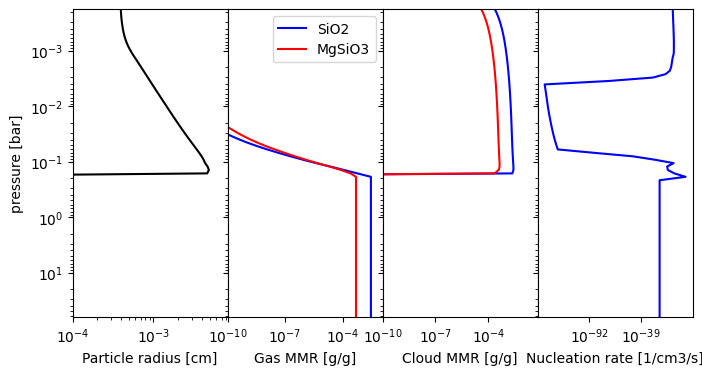

In [8]:
import matplotlib.pyplot as plt

# ==== plot results
fig, ax = plt.subplots(1, 4, figsize=(8,4))
ax[0].plot(ds['cloud_radius'][:-2], ds['pressure'][:-2], color='k')
ax[2].plot(ds['cloud_mmr'][0], ds['pressure'], color='blue')
ax[2].plot(ds['cloud_mmr'][1], ds['pressure'], color='red')
ax[1].plot(ds['gas_mmr'][0], ds['pressure'], color='blue', label='SiO2')
ax[1].plot(ds['gas_mmr'][1], ds['pressure'], color='red', label='MgSiO3')
ax[3].plot(ds['nucleation_rate'][0], ds['pressure'], color='blue')

# ==== make the plot pretty
for i, axi in enumerate(ax):
    axi.set_ylim(bottom=ds['pressure'][-1], top=ds['pressure'][0])
    axi.set_yscale('log')
    axi.set_xscale('log')
    if i > 0:
        ax[i].get_yaxis().set_ticklabels([])
plt.subplots_adjust(wspace=0)
ax[0].set_ylabel('pressure [bar]')
ax[1].set_xlabel('Gas MMR [g/g]')
ax[2].set_xlabel('Cloud MMR [g/g]')
ax[3].set_xlabel('Nucleation rate [1/cm3/s]')
ax[0].set_xlabel('Particle radius [cm]')
ax[0].set_xlim(1e-4)
ax[1].set_xlim(1e-10)
ax[2].set_xlim(1e-10)
ax[1].legend()
plt.show()